In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/arxiv/arxiv-metadata-oai-snapshot.json


In [2]:
import json
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from tqdm import tqdm

json_path = "/kaggle/input/arxiv/arxiv-metadata-oai-snapshot.json"

records = []
with open(json_path, 'r') as f:
    for i, line in enumerate(f):
        if i > 50000:  # adjust limit based on memory
            break
        records.append(json.loads(line))

df = pd.DataFrame(records)
df.head()

,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
0,0704.0001,Pavel Nadolsky,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...",Calculation of prompt diphoton production cros...,"37 pages, 15 figures; published version","Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,ANL-HEP-PR-07-12,hep-ph,None,A fully differential calculation in perturba...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2008-11-26,"[[Balázs, C., ], [Berger, E. L., ], [Nadolsky,..."
1,0704.0002,Louis Theran,Ileana Streinu and Louis Theran,Sparsity-certifying Graph Decompositions,To appear in Graphs and Combinatorics,None,None,None,math.CO cs.CG,http://arxiv.org/licenses/nonexclusive-distrib...,"We describe a new algorithm, the $(k,\ell)$-...","[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2008-12-13,"[[Streinu, Ileana, ], [Theran, Louis, ]]"
2,0704.0003,Hongjun Pan,Hongjun Pan,The evolution of the Earth-Moon system based o...,"23 pages, 3 figures",None,None,None,physics.gen-ph,None,The evolution of Earth-Moon system is descri...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007...",2008-01-13,"[[Pan, Hongjun, ]]"
3,0704.0004,David Callan,David Callan,A determinant of Stirling cycle numbers counts...,11 pages,None,None,None,math.CO,None,We show that a determinant of Stirling cycle...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2007-05-23,"[[Callan, David, ]]"
4,0704.0005,Alberto Torchinsky,Wael Abu-Shammala and Alberto Torchinsky,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,None,"Illinois J. Math. 52 (2008) no.2, 681-689",None,None,math.CA math.FA,None,In this paper we show how to compute the $\L...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2013-10-15,"[[Abu-Shammala, Wael, ], [Torchinsky, Alberto, ]]"


In [3]:
import ast

def extract_authors(parsed_field):
    try:
        authors = ast.literal_eval(parsed_field) if isinstance(parsed_field, str) else parsed_field
        return [' '.join([a for a in author if a]).strip() for author in authors if author]
    except:
        return []

df['clean_authors'] = df['authors_parsed'].apply(extract_authors)

df = df[df['clean_authors'].apply(lambda x: len(x) > 1)]

print(df['clean_authors'].head(5))

0    [Balázs C., Berger E. L., Nadolsky P. M., Yuan...
1                       [Streinu Ileana, Theran Louis]
4              [Abu-Shammala Wael, Torchinsky Alberto]
5                              [Pong Y. H., Law C. K.]
6    [Corichi Alejandro, Vukasinac Tatjana, Zapata ...
Name: clean_authors, dtype: object


In [4]:
df['authors'] = df['authors'].apply(lambda x: [a.strip() for a in x.split(',')])

df = df[df['authors'].apply(lambda x: len(x) > 1)]

print("Total papers:", len(df))

Total papers: 28677


In [5]:
G = nx.Graph()

for authors in tqdm(df['clean_authors'], desc="Building co-author graph"):
    for a1, a2 in combinations(authors, 2):
        if G.has_edge(a1, a2):
            G[a1][a2]['weight'] += 1
        else:
            G.add_edge(a1, a2, weight=1)

print("Total authors:", G.number_of_nodes())
print("Total co-author links:", G.number_of_edges())

Building co-author graph: 100%|██████████| 28677/28677 [00:01<00:00, 17204.76it/s]


Total authors: 78086
Total co-author links: 519004


In [6]:
degree_dict = dict(G.degree())
top_authors = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 Authors by Collaboration Count:")
for a, d in top_authors:
    print(f"{a}: {d}")

print("Density:", nx.density(G))
print("Average clustering coefficient:", nx.average_clustering(G))

Top 10 Authors by Collaboration Count:
Sarkar S.: 418
Gehrels N.: 377
Giorgi M.: 367
Delgado C.: 364
Pimenta M.: 362
Giommi P.: 353
Gianotti F.: 353
Longo F.: 349
Castro-Tirado A. J.: 349
Biland A.: 333
Density: 0.00017023933322221502
Average clustering coefficient: 0.8051187592970495


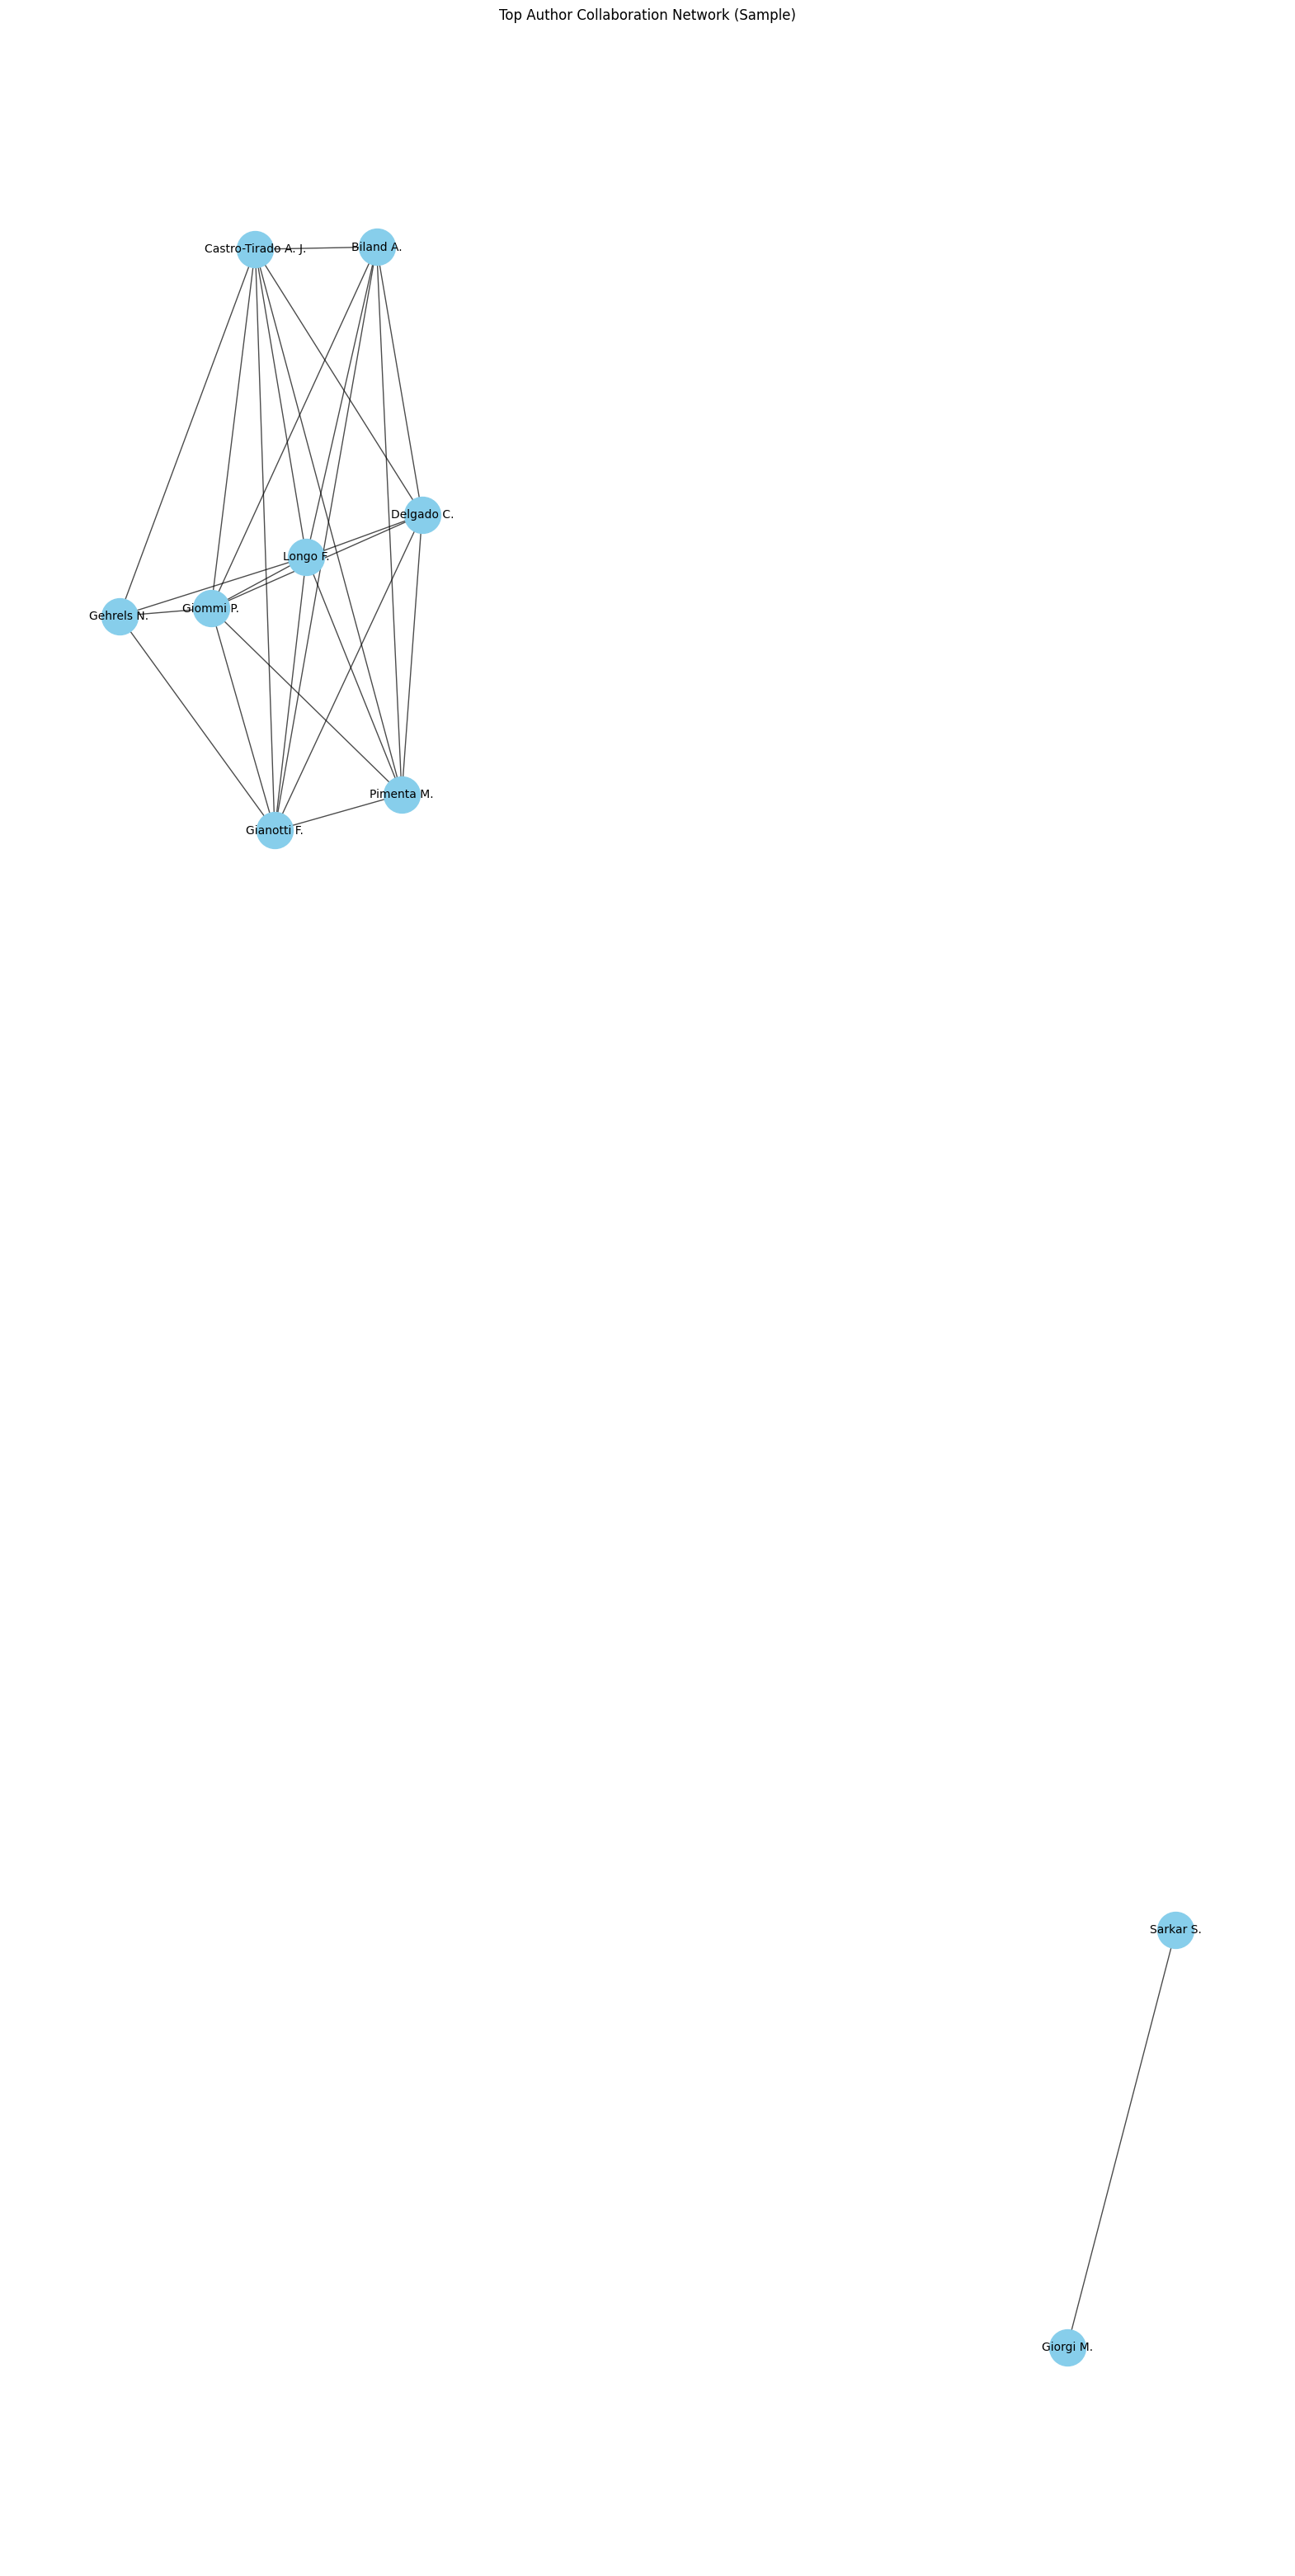

In [7]:
top_nodes = [n for n, _ in top_authors[:50]]
subG = G.subgraph(top_nodes)

plt.figure(figsize=(20, 40))
pos = nx.spring_layout(subG, k=0.5, seed=42)
nx.draw_networkx_nodes(subG, pos, node_size=1000, node_color='skyblue')
nx.draw_networkx_edges(subG, pos, width=1, alpha=0.7)
nx.draw_networkx_labels(subG, pos, font_size=10)
plt.title("Top Author Collaboration Network (Sample)")
plt.axis('off')
plt.show()